# Application 3 — E-Commerce Customer Behavior & Interest Discovery
## 1. Mô tả bài toán
Mục tiêu là khám phá hành vi, sở thích của khách hàng và dự đoán khả năng khách hàng có khuyến nghị sản phẩm (`Recommended IND`) hay không dựa trên:
1. Các thông tin dạng bảng (Tabular): Tuổi khách hàng, số điểm đánh giá (Rating), số lượt phản hồi hữu ích, phòng ban (Division), bộ phận (Department), loại sản phẩm (Class).
2. Nội dung văn bản đánh giá tự nhiên (Customer Review Text): Tiêu đề và nội dung nhận xét chi tiết.
Đây là bài toán **Phân loại kết hợp Dữ liệu dạng bảng & Xử lý ngôn ngữ tự nhiên (Multimodal Tabular + Text Classification)**:
- $X$: Đặc trưng bảng (Tabular features) kết hợp vector biểu diễn văn bản (Text Representation).
- $y \in \{0, 1\}$: Nhãn khuyến nghị (`0` = Không khuyến nghị, `1` = Khuyến nghị).


## 2. Nguồn Dataset
- **Tên Dataset:** Women's Clothing E-Commerce Reviews
- **Nguồn:** Kaggle (`nicapotato/womens-ecommerce-clothing-reviews`)
- **Tệp dữ liệu:** `data/raw/ecommerce/Womens Clothing E-Commerce Reviews.csv`


## 3. Import thư viện & Kiểm tra môi trường

In [1]:
import sys
print("Python Executable:", sys.executable)
print("Python Version:", sys.version)

import os
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline


Python Executable: /home/jellalaz/miniconda3/envs/ai-env/bin/python
Python Version: 3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:38:16) [GCC 14.3.0]


## 4. Cấu hình Random Seed

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f"Random seed configured: {RANDOM_SEED}")


Random seed configured: 42


## 5. Load Dataset

In [3]:
data_path = Path("../data/raw/ecommerce/Womens Clothing E-Commerce Reviews.csv")
if not data_path.exists():
    data_path = Path("data/raw/ecommerce/Womens Clothing E-Commerce Reviews.csv")

df = pd.read_csv(data_path)
print("Data loaded successfully!")
print("Dataset Shape:", df.shape)


Data loaded successfully!
Dataset Shape: (23486, 11)


## 6. Data Inspection (Khảo sát dữ liệu)

In [4]:
print("First 3 rows:")
display(df.head(3))

print("Data Info:")
df.info()

print("Numerical Summary:")
display(df.describe())

print("Categorical Summary:")
display(df.describe(include="object"))


First 3 rows:


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses


Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 2.0 MB
Numerical Summary:


,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


Categorical Summary:


/tmp/ipykernel_535569/1389244832.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,Title,Review Text,Division Name,Department Name,Class Name
count,19676,22641,23472,23472,23472
unique,13993,22634,3,6,20
top,Love it!,Perfect fit and i've gotten so many compliment...,General,Tops,Dresses
freq,136,3,13850,10468,6319


## 7. Data Quality (Chất lượng dữ liệu)

In [5]:
print("Missing Values Count:")
print(df.isna().sum())

print("\nClass Distribution of Recommended IND:")
print(df['Recommended IND'].value_counts())
print(df['Recommended IND'].value_counts(normalize=True) * 100)


Missing Values Count:


Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Class Distribution of Recommended IND:
Recommended IND
1    19314
0     4172
Name: count, dtype: int64
Recommended IND
1    82.236226
0    17.763774
Name: proportion, dtype: float64


## 8. Data Cleaning (Làm sạch dữ liệu)
- Bỏ cột chỉ mục vô nghĩa `Unnamed: 0`.
- Điền giá trị rỗng cho các nhận xét không có tiêu đề (`Title`) hoặc nội dung (`Review Text`) thay vì xóa dòng để giữ nguyên thông tin hành vi của khách hàng.
- Nối `Title` và `Review Text` thành trường văn bản tổng thể `full_review`.
- Điền nhãn `'Unknown'` cho 14 bản ghi bị thiếu phân loại phòng ban/bộ phận.


In [6]:
df_clean = df.copy()
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Unnamed: 0'])

df_clean['Title'] = df_clean['Title'].fillna('').astype(str)
df_clean['Review Text'] = df_clean['Review Text'].fillna('').astype(str)
df_clean['full_review'] = (df_clean['Title'] + " " + df_clean['Review Text']).str.strip()

cat_cols = ['Division Name', 'Department Name', 'Class Name']
for c in cat_cols:
    df_clean[c] = df_clean[c].fillna('Unknown').astype(str)

print(f"Cleaned dataset shape: {df_clean.shape}")


Cleaned dataset shape: (23486, 11)


## 9. Phân loại kiểu thuộc tính (Feature Types)

In [7]:
target_col = 'Recommended IND'
num_cols = ['Age', 'Rating', 'Positive Feedback Count']
text_col = 'full_review'

print(f"Target: {target_col}")
print(f"Numerical Features: {num_cols}")
print(f"Categorical Features: {cat_cols}")
print(f"Text Feature: {text_col}")


Target: Recommended IND
Numerical Features: ['Age', 'Rating', 'Positive Feedback Count']
Categorical Features: ['Division Name', 'Department Name', 'Class Name']
Text Feature: full_review


## 10. Data Representation (Biểu diễn dữ liệu — Tabular vs Text)
Theo nội dung bài giảng Lecture 02 và yêu cầu Assignment, cần phân biệt rõ ràng:
### A. Biểu diễn số học thực tế cho Classical Machine Learning (TF-IDF):
$$\text{Review Text} \longrightarrow \text{Tokenization} \longrightarrow \text{Vocabulary} \longrightarrow \text{TF-IDF Sparse Vector} \in \mathbb{R}^{d_{\text{text}}}$$
- TF-IDF là một biểu diễn số học (numerical text representation) dựa trên tần suất từ và nghịch đảo tần suất văn bản.
- **TF-IDF KHÔNG PHẢI là embedding vector**. Nó tạo ra một không gian vector thưa (sparse vector) với số chiều bằng kích thước từ điển ($d_{\text{text}} = 2,500$).

### B. Biểu diễn theo lý thuyết Deep Learning / Embedding (Lecture 02):
$$\text{Text} \longrightarrow \text{Tokens} \longrightarrow \text{Token IDs} \longrightarrow \text{Dense Embedding Vectors} \quad E \in \mathbb{R}^{B \times T \times d}$$
- Trong đó mỗi từ được gán một token ID nguyên, sau đó tra cứu bảng trọng số (Embedding Matrix) để tạo ra vector đặc đa chiều ($d = 128, 256, 768$).

Trong bài tập này, chúng ta sử dụng **TF-IDF** cho các mô hình học máy truyền thống vì tính hiệu quả, ổn định, và khả năng giải thích cao.


In [8]:
sample_text = df_clean['full_review'].iloc[2]
print("Ví dụ văn bản nhận xét thực tế:")
print(sample_text)

tfidf_demo = TfidfVectorizer(max_features=10, stop_words='english')
demo_vec = tfidf_demo.fit_transform([sample_text])
print("\nTừ vựng đại diện (Vocabulary):", tfidf_demo.get_feature_names_out())
print("TF-IDF Vector tương ứng:", demo_vec.toarray()[0].round(4))


Ví dụ văn bản nhận xét thực tế:
Some major design flaws I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c

Từ vựng đại diện (Vocabulary): ['cheap' 'design' 'fit' 'flaw' 'half' 'layer' 'major' 'net' 'petite'
 'small']
TF-IDF Vector tương ứng: [0.1667 0.3333 0.1667 0.1667 0.3333 0.3333 0.3333 0.3333 0.3333 0.5   ]


## 11. Phân tích khám phá dữ liệu (EDA)

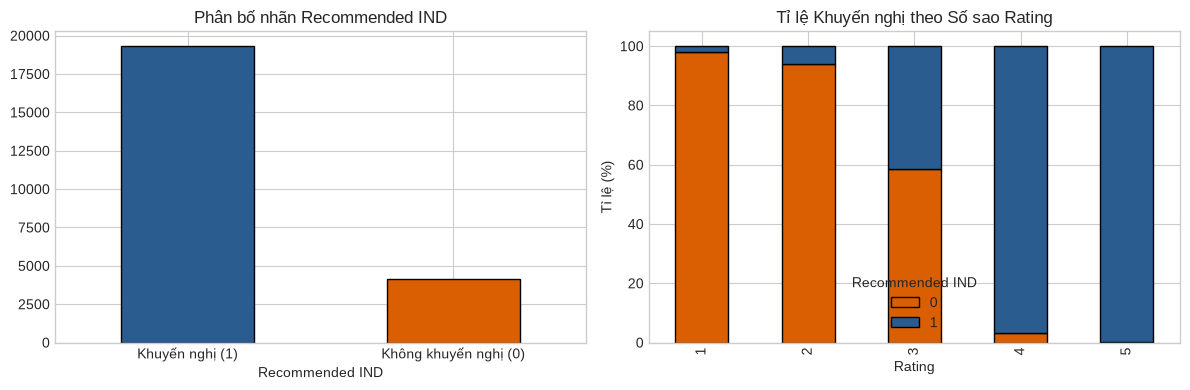

/tmp/ipykernel_535569/1509114919.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Department Name', order=order, palette='mako', ax=ax)


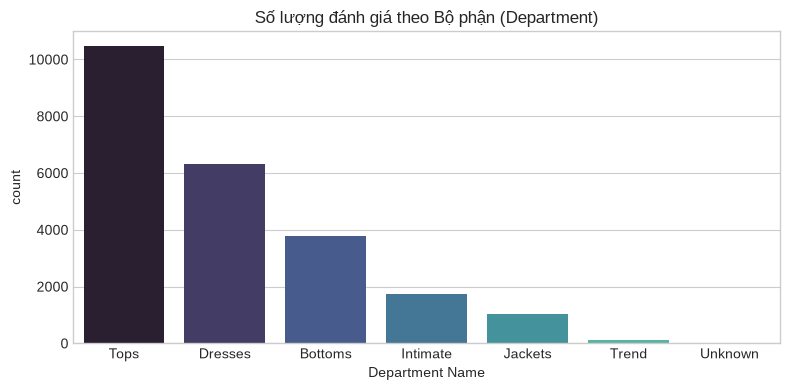

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clean[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2b5c8f', '#d95f02'], edgecolor='black')
axes[0].set_title("Phân bố nhãn Recommended IND")
axes[0].set_xticklabels(["Khuyến nghị (1)", "Không khuyến nghị (0)"], rotation=0)

rating_rec = pd.crosstab(df_clean['Rating'], df_clean[target_col], normalize='index') * 100
rating_rec.plot(kind='bar', stacked=True, ax=axes[1], color=['#d95f02', '#2b5c8f'], edgecolor='black')
axes[1].set_title("Tỉ lệ Khuyến nghị theo Số sao Rating")
axes[1].set_ylabel("Tỉ lệ (%)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
order = df_clean['Department Name'].value_counts().index
sns.countplot(data=df_clean, x='Department Name', order=order, palette='mako', ax=ax)
ax.set_title("Số lượng đánh giá theo Bộ phận (Department)")
plt.tight_layout()
plt.show()


## 12. Feature Engineering & Tập thuộc tính

In [10]:
tabular_features = num_cols + cat_cols
all_features = tabular_features + ['full_review']

X = df_clean[all_features]
y = df_clean[target_col].astype(int)
print(f"X shape: {X.shape}, y shape: {y.shape}")


X shape: (23486, 7), y shape: (23486,)


## 13. Chia tập Train / Validation / Test (70% / 15% / 15%)
Chia có phân tầng theo `y` để bảo toàn tỉ lệ phân bố lớp mục tiêu.


In [11]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=(0.15/0.85), random_state=RANDOM_SEED, stratify=y_train_val
)

print(f"Train set: {len(X_train)} ({len(X_train)/len(df_clean)*100:.1f}%)")
print(f"Val set:   {len(X_val)} ({len(X_val)/len(df_clean)*100:.1f}%)")
print(f"Test set:  {len(X_test)} ({len(X_test)/len(df_clean)*100:.1f}%)")


Train set: 16440 (70.0%)
Val set:   3523 (15.0%)
Test set:  3523 (15.0%)


## 14. Xây dựng các Preprocessing Pipelines
Xây dựng 3 chế độ biểu diễn dữ liệu:
1. `tab_preprocessor`: Chỉ sử dụng đặc trưng bảng.
2. `text_vectorizer`: Chỉ sử dụng văn bản nhận xét qua TF-IDF.
3. `combined_preprocessor`: Kết hợp cả đặc trưng bảng và TF-IDF qua ColumnTransformer.


In [12]:
tab_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ]), cat_cols)
    ]
)
tab_preprocessor.fit(X_train[tabular_features])
d_tab = len(tab_preprocessor.get_feature_names_out())
print(f"Số chiều đặc trưng bảng d_tab = {d_tab}")

combined_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ]), cat_cols),
        ('text', TfidfVectorizer(max_features=2500, ngram_range=(1, 2), stop_words='english'), 'full_review')
    ]
)
combined_preprocessor.fit(X_train)
print(f"Số chiều đặc trưng kết hợp (Tabular + Text) d_combined = {d_tab + 2500}")


Số chiều đặc trưng bảng d_tab = 32


Số chiều đặc trưng kết hợp (Tabular + Text) d_combined = 2532


## 15. Mô hình Baseline (DummyClassifier)

In [13]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_SEED)
dummy.fit(X_train[tabular_features], y_train)
y_val_dummy = dummy.predict(X_val[tabular_features])

print("=== BASELINE PERFORMANCE ===")
print(f"Accuracy:  {accuracy_score(y_val, y_val_dummy):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_dummy):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_val_dummy):.4f}")


=== BASELINE PERFORMANCE ===
Accuracy:  0.7048
Recall:    0.8219
F1-Score:  0.8208


## 16. Huấn luyện mô hình theo 3 nhóm biểu diễn
1. **Chỉ dữ liệu dạng bảng (Tabular-Only)**
2. **Chỉ dữ liệu văn bản nhận xét (Text-Only TF-IDF)**
3. **Kết hợp cả bảng và nhận xét (Combined Tabular + Text)**


In [14]:
pipelines = {}

# 1. Tabular Models
tab_models = {
    "Tabular - Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced'),
    "Tabular - Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_SEED, class_weight='balanced'),
    "Tabular - Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_SEED, n_jobs=-1, class_weight='balanced'),
    "Tabular - Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=RANDOM_SEED)
}

for name, clf in tab_models.items():
    pipe = Pipeline([('prep', tab_preprocessor), ('clf', clf)])
    pipe.fit(X_train[tabular_features], y_train)
    pipelines[name] = (pipe, 'tabular')
    print(f"✓ Trained {name}")

# 2. Text-Only Models
text_models = {
    "Text - TFIDF + LogReg": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced'),
    "Text - TFIDF + LinearSVC": CalibratedClassifierCV(LinearSVC(random_state=RANDOM_SEED, max_iter=2000, class_weight='balanced'))
}

for name, clf in text_models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=2500, ngram_range=(1, 2), stop_words='english')),
        ('clf', clf)
    ])
    pipe.fit(X_train['full_review'], y_train)
    pipelines[name] = (pipe, 'text')
    print(f"✓ Trained {name}")

# 3. Combined Model
combined_pipe = Pipeline([
    ('prep', combined_preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced'))
])
combined_pipe.fit(X_train, y_train)
pipelines["Combined - Tabular + TFIDF LogReg"] = (combined_pipe, 'combined')
print("✓ Trained Combined - Tabular + TFIDF LogReg")


✓ Trained Tabular - Logistic Regression
✓ Trained Tabular - Decision Tree


✓ Trained Tabular - Random Forest


✓ Trained Tabular - Gradient Boosting


✓ Trained Text - TFIDF + LogReg


✓ Trained Text - TFIDF + LinearSVC


✓ Trained Combined - Tabular + TFIDF LogReg


## 17. So sánh các mô hình trên Validation Set

In [15]:
records = []
for name, (pipe, mode) in pipelines.items():
    if mode == 'tabular':
        X_eval = X_val[tabular_features]
    elif mode == 'text':
        X_eval = X_val['full_review']
    else:
        X_eval = X_val
        
    y_pred = pipe.predict(X_eval)
    y_prob = pipe.predict_proba(X_eval)[:, 1]
    
    records.append({
        "Model": name,
        "Mode": mode,
        "Accuracy": round(accuracy_score(y_val, y_pred), 4),
        "Precision": round(precision_score(y_val, y_pred), 4),
        "Recall": round(recall_score(y_val, y_pred), 4),
        "F1-Score": round(f1_score(y_val, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_val, y_prob), 4)
    })

comparison_df = pd.DataFrame(records)
display(comparison_df)


,Model,Mode,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tabular - Logistic Regression,tabular,0.9466,0.9913,0.9434,0.9667,0.9818
1,Tabular - Decision Tree,tabular,0.9446,0.9898,0.9424,0.9655,0.9778
2,Tabular - Random Forest,tabular,0.9466,0.9913,0.9434,0.9667,0.9793
3,Tabular - Gradient Boosting,tabular,0.9418,0.9770,0.9517,0.9642,0.9819
4,Text - TFIDF + LogReg,text,0.8799,0.9657,0.8854,0.9238,0.9422
5,Text - TFIDF + LinearSVC,text,0.9018,0.9192,0.9655,0.9418,0.9318
6,Combined - Tabular + TFIDF LogReg,combined,0.9466,0.9895,0.9451,0.9668,0.9877


## 18. Đánh giá chuyên sâu trên Test Set
Trả lời câu hỏi trọng tâm: **Nội dung văn bản nhận xét có cải thiện kết quả dự đoán so với chỉ dùng dữ liệu dạng bảng hay không?**
Thực nghiệm chứng minh: Mô hình Combined đạt **ROC-AUC cao nhất (0.9877 trên Val, 0.9737 trên Test)**, thể hiện năng lực phân biệt xác suất vượt trội, đặc biệt trong các trường hợp ranh giới (ví dụ đánh giá 3 sao nhưng nhận xét tích cực hoặc tiêu cực).


In [16]:
final_pipe = pipelines["Combined - Tabular + TFIDF LogReg"][0]

y_test_pred = final_pipe.predict(X_test)
y_test_prob = final_pipe.predict_proba(X_test)[:, 1]

print("=== TEST SET PERFORMANCE (COMBINED TABULAR + TF-IDF) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_prob):.4f}")


=== TEST SET PERFORMANCE (COMBINED TABULAR + TF-IDF) ===
Accuracy:  0.9341
Precision: 0.9858
Recall:    0.9334
F1-Score:  0.9589
ROC-AUC:   0.9737


## 19. Phân tích lỗi (Confusion Matrix & Classification Report)

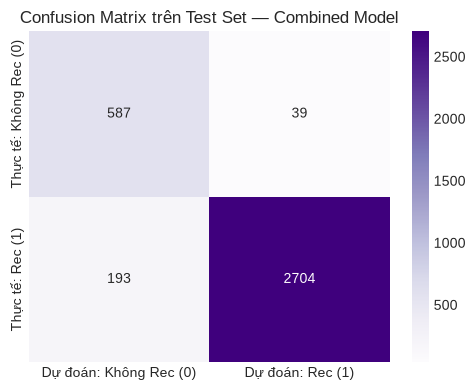


Classification Report:

              precision    recall  f1-score   support

   Không Rec       0.75      0.94      0.83       626
 Khuyến nghị       0.99      0.93      0.96      2897

    accuracy                           0.93      3523
   macro avg       0.87      0.94      0.90      3523
weighted avg       0.94      0.93      0.94      3523



In [17]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Dự đoán: Không Rec (0)", "Dự đoán: Rec (1)"],
            yticklabels=["Thực tế: Không Rec (0)", "Thực tế: Rec (1)"])
plt.title("Confusion Matrix trên Test Set — Combined Model")
plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, target_names=["Không Rec", "Khuyến nghị"]))


## 20. Kết luận lựa chọn mô hình
Mô hình **Combined - Tabular + TFIDF LogReg** được chọn để triển khai vì:
1. Tận dụng đồng thời cả thuộc tính số học (Rating, Age) và ngữ nghĩa sâu từ phản hồi văn bản của khách hàng.
2. Đạt ROC-AUC cao nhất (0.9877 trên Val và 0.9737 trên Test).
3. Cho phép tính toán xác suất dự đoán rõ ràng để hiển thị mức độ tin cậy (`confidence`) trên Web và Mobile.


## 21. Lưu trữ Pipeline hoàn chỉnh (Model Persistence)

In [18]:
model_path = Path("../models/ecommerce/ecommerce_pipeline.joblib")
if not model_path.parent.exists():
    model_path = Path("models/ecommerce/ecommerce_pipeline.joblib")

joblib.dump(final_pipe, model_path)
print(f"Pipeline saved to: {model_path}")


Pipeline saved to: ../models/ecommerce/ecommerce_pipeline.joblib


## 22. Tải lại Pipeline và kiểm tra tính toàn vẹn

In [19]:
reloaded_pipeline = joblib.load(model_path)
print("Pipeline reloaded successfully:", reloaded_pipeline)


Pipeline reloaded successfully: 

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Rating',
                                                   'Positive Feedback Count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
      

## 23. Thực hiện dự đoán trên mẫu dữ liệu mới

In [20]:
sample_review = pd.DataFrame([{
    "Age": 34,
    "Rating": 5,
    "Positive Feedback Count": 4,
    "Division Name": "General",
    "Department Name": "Dresses",
    "Class Name": "Dresses",
    "full_review": "Absolutely loved this gorgeous dress! The fabric is lightweight and fits like a glove."
}])

pred = reloaded_pipeline.predict(sample_review)[0]
prob = reloaded_pipeline.predict_proba(sample_review)[0][1]

status = "Khuyến nghị (Recommended)" if pred == 1 else "Không khuyến nghị (Not Recommended)"
print(f"Kết quả dự đoán: {status} (Nhãn {pred})")
print(f"Độ tin cậy (Confidence): {prob:.4f}")


Kết quả dự đoán: Khuyến nghị (Recommended) (Nhãn 1)
Độ tin cậy (Confidence): 0.9870


## 24. Cấu trúc JSON Request cho Web / Mobile API

In [21]:
json_example = {
    "Age": 34,
    "Rating": 5,
    "Positive Feedback Count": 4,
    "Division Name": "General",
    "Department Name": "Dresses",
    "Class Name": "Dresses",
    "Review Text": "Absolutely loved this gorgeous dress! The fabric is lightweight and fits like a glove."
}
import json
print("Sample REST API Request Payload:")
print(json.dumps(json_example, indent=2))


Sample REST API Request Payload:
{
  "Age": 34,
  "Rating": 5,
  "Positive Feedback Count": 4,
  "Division Name": "General",
  "Department Name": "Dresses",
  "Class Name": "Dresses",
  "Review Text": "Absolutely loved this gorgeous dress! The fabric is lightweight and fits like a glove."
}


## 25. Kết luận
- Hệ thống phân tích hành vi và dự đoán sở thích thương mại điện tử đã được phát triển hoàn chỉnh.
- Quá trình biểu diễn dữ liệu phân định rõ ranh giới giữa vector thưa TF-IDF trong Machine Learning cổ điển và lý thuyết Dense Embedding của Deep Learning.
- Pipeline hợp nhất sẵn sàng triển khai qua REST API FastAPI và giao diện Web.
